# HCCST performed spatial clustering on DLPFC 151671


## 1. Environment

Import required packages, set random seeds, configure deterministic behavior, and select the running device.


In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120

# Add the project root path so that local HCCST modules can be imported.
# Modify CODE_ROOT if your project is stored in another directory.
CODE_ROOT = "/root/autodl-tmp"
sys.path.insert(0, CODE_ROOT)

from HCCST.HCCST import MultimodalHCCST
from HCCST.preprocess import fix_seed

random_seed = 42
fix_seed(random_seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda:0


## 2. Parameters

Define dataset paths and hyperparameters.  


In [8]:
# Dataset identifier and root directory.
dataset = "151671"
dataset_root = "/root/autodl-tmp/Dataset/DLPFC"
dataset_path = os.path.join(dataset_root, dataset)
metadata_path = os.path.join(dataset_path, "metadata.tsv")

# Default number of clusters used when no manual annotation is available. For DLPFC, this value will be replaced by the number of annotated regions.
default_n_clusters = 7

epochs = 550
dim_input = 3000
dim_output = 48

alpha = 8     # reconstruction loss weight
beta = 0.1    # cross-modal contrastive loss weight
gamma = 0.7   # modality consistency loss weight
delta = 0.1   # prototype regularization loss weight
embedding_lambda = 0.1 # Weight used for late fusion of gene and image embeddings.

# Clustering parameters.
radius = 12
refinement = True
cluster_tool = "mclust"

# Output directory for saving the trained AnnData object and figures.
output_dir = os.path.join(".", "outputs", "DLPFC")
os.makedirs(output_dir, exist_ok=True)

print("dataset_path =", dataset_path)
print("metadata_path =", metadata_path)


dataset_path = /root/autodl-tmp/Dataset/DLPFC/151671
metadata_path = /root/autodl-tmp/Dataset/DLPFC/151671/metadata.tsv


## 3. Load Data

Load 10x Visium data, extract the high-resolution histology image, and read manual layer annotations from `metadata.tsv`.


In [3]:
adata = sc.read_visium(
    dataset_path,
    count_file="filtered_feature_bc_matrix.h5",
    load_images=True,
)

adata.var_names_make_unique()

lib_id = list(adata.uns["spatial"].keys())[0]
image_data = adata.uns["spatial"][lib_id]["images"]["hires"]

df_meta = pd.read_csv(metadata_path, sep="\t")

if "layer_guess" in df_meta.columns:
    adata.obs["ground_truth"] = df_meta["layer_guess"].values

if "ground_truth" in adata.obs:
    valid_mask = pd.notna(adata.obs["ground_truth"])
    adata = adata[valid_mask].copy()
    adata.obs["ground_truth"] = adata.obs["ground_truth"].astype(str)
    n_clusters = len(adata.obs["ground_truth"].unique())
else:
    # For unlabeled datasets, use a predefined cluster number.
    n_clusters = default_n_clusters

print("adata shape:", adata.shape)
print("hires image shape:", image_data.shape)
print("n_clusters =", n_clusters)


adata shape: (4093, 33538)
hires image shape: (2000, 2000, 3)
n_clusters = 5


## 4. Train HCCST

Initialize the multimodal HCCST model and train it to obtain clustering embeddings.


In [4]:
# Initialize the multimodal HCCST model.
multimodal_model = MultimodalHCCST(
    adata=adata,
    image_data=image_data,
    device=device,
    epochs=epochs,
    dim_input=dim_input,
    dim_output=dim_output,
    random_seed=random_seed,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    delta=delta,
    num_cell_types=n_clusters,
)

print(multimodal_model.adata.uns.get("mor_adj_stats", None))
print("embedding_lambda =", multimodal_model.embedding_lambda)

# Train the multimodal model.
start_time = time.time()
adata_result = multimodal_model.train_multimodal()
elapsed = time.time() - start_time

print(f"training done, elapsed: {elapsed:.2f} s")
print("clustering embedding:", adata_result.uns.get("emb_key"))


{'pca_dim': 16, 'nonzero_edges': 18431, 'mean_weight': 0.9967739582061768, 'topk_keep': None}
embedding_lambda = 0.1


Joint training: 100%|██████████| 385/385 [03:30<00:00,  1.83it/s]


training done, elapsed: 222.10 s
clustering embedding: late_fusion_embedding_lambda_0.1


## 5. Cluster and Evaluate

Cluster the learned HCCST embeddings and evaluate the results using ARI and NMI when ground-truth annotations are available.


In [5]:
multimodal_model.adata = adata_result.copy()

# Cluster the learned embeddings.
multimodal_model.cluster(
    tool=cluster_tool,
    radius=radius,
    key="emb",
    refinement=refinement,
    n_clusters=n_clusters,
)

adata_multimodal = multimodal_model.adata.copy()
group_key = "domain"

adata_multimodal.obs[group_key] = adata_multimodal.obs[group_key].astype(str)

if "ground_truth" in adata_multimodal.obs:
    adata_multimodal.obs["ground_truth"] = adata_multimodal.obs["ground_truth"].astype(str)

# Calculate clustering metrics.
metrics_dict = multimodal_model.calculate_metrics(
    pred_col=group_key,
    true_col="ground_truth",
    mode="auto",
)
metrics_df = pd.DataFrame([metrics_dict], index=[cluster_tool])

ARI = float(metrics_dict["ARI"]) if "ARI" in metrics_dict else float("nan")
NMI = float(metrics_dict["NMI"]) if "NMI" in metrics_dict else float("nan")

print(metrics_df)


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Refining labels with radius 12
             ARI       NMI
mclust  0.820136  0.778413


## 6. Save and Visualize

Save the clustering results and generate spatial, UMAP, and PAGA visualizations.


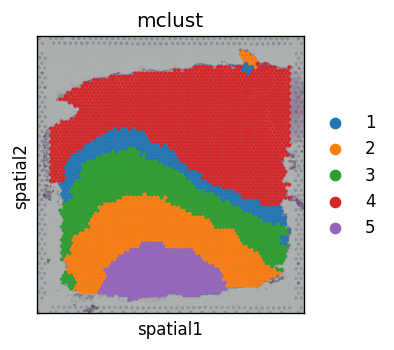

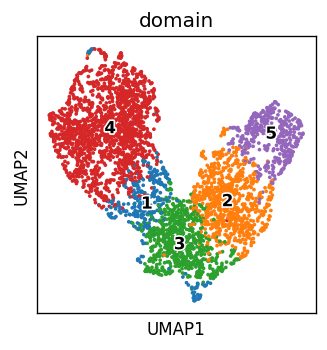

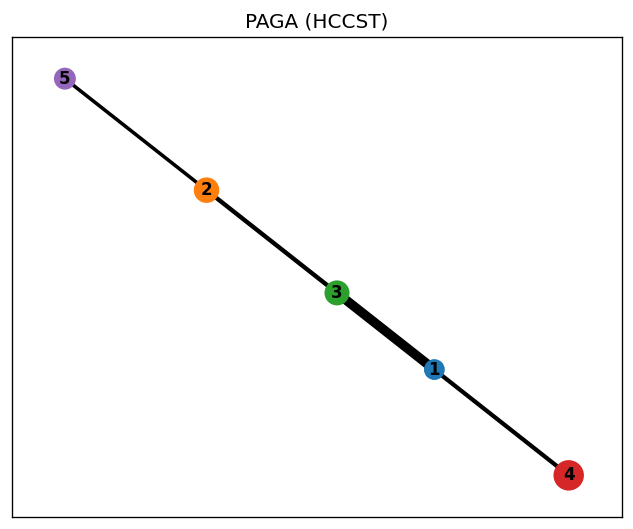

h5ad: ./outputs/DLPFC/DLPFC151671_ARI0.820.h5ad
spatial: ./outputs/DLPFC/DLPFC151671_ARI0.820_spatial.jpg
umap: ./outputs/DLPFC/DLPFC151671_ARI0.820_umap.jpg
paga: ./outputs/DLPFC/DLPFC151671_ARI0.820_paga.jpg


In [9]:
file_prefix = f"DLPFC{dataset}_ARI{ARI:.3f}"
h5ad_path = os.path.join(output_dir, f"{file_prefix}.h5ad")
spatial_path = os.path.join(output_dir, f"{file_prefix}_spatial.jpg")
umap_path = os.path.join(output_dir, f"{file_prefix}_umap.jpg")
paga_path = os.path.join(output_dir, f"{file_prefix}_paga.jpg")

adata_multimodal.write(h5ad_path)

# Visualize spatial domains on the histology image.
plt.close("all")
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(
    adata_multimodal,
    img_key="hires",
    color=group_key,
    size=1.5,
    title=cluster_tool,
    show=False,
)
plt.savefig(spatial_path, bbox_inches="tight", dpi=300)
plt.show()

adata_plot = adata_multimodal.copy()
adata_plot.obs[group_key] = adata_plot.obs[group_key].astype("category")

if "emb_pca" not in adata_plot.obsm:
    emb_mat = np.asarray(adata_plot.obsm["emb"])
    n_comp = min(30, emb_mat.shape[1], max(1, emb_mat.shape[0] - 1))
    adata_plot.obsm["emb_pca"] = PCA(
        n_components=n_comp,
        random_state=random_seed,
    ).fit_transform(emb_mat)

# Compute UMAP based on the learned embedding and save UMAP visualization
sc.pp.neighbors(adata_plot, use_rep="emb_pca", n_neighbors=10)
sc.tl.umap(adata_plot, random_state=random_seed)

plt.close("all")
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(
    adata_plot,
    color=group_key,
    legend_loc="on data",
    s=20,
    legend_fontoutline="2",
    show=False,
)
plt.savefig(umap_path, bbox_inches="tight", dpi=300)
plt.show()

# Run PAGA and save PAGA graph visualization.
sc.tl.paga(adata_plot, groups=group_key)

plt.close("all")
plt.rcParams["figure.figsize"] = (6, 5)
sc.pl.paga(
    adata_plot,
    color=[group_key],
    threshold=0.01,
    node_size_scale=1.2,
    edge_width_scale=1.2,
    title="PAGA (HCCST)",
    show=False,
)
plt.savefig(paga_path, bbox_inches="tight", dpi=300)
plt.show()

print("h5ad:", h5ad_path)
print("spatial:", spatial_path)
print("umap:", umap_path)
print("paga:", paga_path)
